# Лабораторная работа 12

Тема: **Vanilla GAN для генерации цифр MNIST в PyTorch**  
Формат: практическая работа с обязательными собственными экспериментами и комментариями.

> Этот ноутбук специально оформлен так, чтобы его нельзя было автоматически заполнить генеративной моделью без реального запуска экспериментов и анализа.  
> Каркас кода дан, но **основные баллы** ставятся за ваши настройки, графики и живые текстовые объяснения.


## 1. Ваше понимание задачи GAN (если не знаетет, что такое GAN - можно гуглить и спрашивать LLM)

Перед запуском кода опишите текущее понимание (8–12 предложений):

1. Для чего нужны генеративно‑состязательные сети (GAN) и чем их цель отличается от классической задачи классификации.  
2. Как вы интуитивно представляете «игру» генератора и дискриминатора: кто что пытается сделать и почему это неустойчивая задача.  
3. Каких визуальных артефактов вы ожидаете от **простого** Vanilla GAN на MNIST (размытость, странные гибриды цифр и т.п.).

Пишите своими словами, как если бы объясняли задачу одногруппнику.


In [ ]:
intro_text = """
Генеративно-состязательные сети нужны для создания новых данных, которые похожи
на реальные. В отличие от обычной классификации, где модель должна определить
класс объекта, GAN пытается научиться генерировать новые примеры. В GAN есть
две нейронные сети: генератор и дискриминатор. Генератор создает изображения из
случайного шума и пытается сделать их максимально похожими на настоящие.
Дискриминатор получает реальные и сгенерированные изображения и пытается
определить, какие из них настоящие, а какие поддельные. Получается своеобразная
игра, где генератор постоянно учится обманывать дискриминатор, а дискриминатор
учится лучше различать изображения. Эта задача считается неустойчивой, потому
что одна сеть может начать обучаться быстрее другой, и тогда процесс генерации
ухудшается. Я ожидаю, что простой Vanilla GAN на MNIST сначала будет создавать
шумные и неразборчивые изображения цифр. Позже изображения станут более похожими
на реальные цифры, но могут появляться размытые контуры или странные гибриды
нескольких цифр одновременно. Также возможно, что генератор начнет слишком часто
рисовать похожие цифры, например только единицы или двойки. Мне кажется, что
качество генерации будет постепенно улучшаться по мере обучения, но идеальных
изображений от простой архитектуры ждать не стоит.
"""
print(intro_text)


Генеративно-состязательные сети нужны для создания новых данных, которые похожи 
на реальные. В отличие от обычной классификации, где модель должна определить 
класс объекта, GAN пытается научиться генерировать новые примеры. В GAN есть 
две нейронные сети: генератор и дискриминатор. Генератор создает изображения из 
случайного шума и пытается сделать их максимально похожими на настоящие. 
Дискриминатор получает реальные и сгенерированные изображения и пытается 
определить, какие из них настоящие, а какие поддельные. Получается своеобразная 
игра, где генератор постоянно учится обманывать дискриминатор, а дискриминатор 
учится лучше различать изображения. Эта задача считается неустойчивой, потому 
что одна сеть может начать обучаться быстрее другой, и тогда процесс генерации 
ухудшается. Я ожидаю, что простой Vanilla GAN на MNIST сначала будет создавать 
шумные и неразборчивые изображения цифр. Позже изображения станут более похожими 
на реальные цифры, но могут появляться размытые ко

## 2. Импорт, настройки и данные (MNIST)


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

import matplotlib.pyplot as plt
import numpy as np
import os

MY_SEED = 42  # при своих экспериментах можете поменять, но зафиксируйте в отчёте
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

# каталог для возможного сохранения картинок
os.makedirs("gan_samples", exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # пиксели в [-1, 1]
])

batch_size = 128

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print("Размер train:", len(train_dataset))

Устройство: cpu
MY_SEED = 42


100%|██████████| 9.91M/9.91M [00:00<00:00, 135MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 46.4MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 81.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


Размер train: 60000


Посмотрим на несколько реальных изображений, которые GAN должен научиться имитировать.


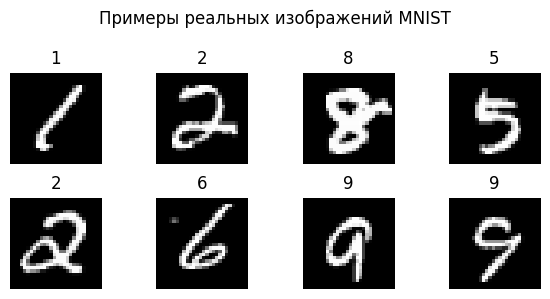

In [ ]:
real_images, real_labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(real_images[i].squeeze(0), cmap="gray")
    plt.title(str(real_labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры реальных изображений MNIST")
plt.tight_layout()
plt.show()

### Мини‑комментарий по данным

Кратко (3–5 предложений) опишите:
- насколько, на ваш взгляд, легко/сложно генератору научиться имитировать такие цифры;  
- какие особенности рукописных цифр могут затруднить генерацию (разные стили, толщина линий и т.п.).


In [ ]:
data_comment = """
Мне кажется, что изображения MNIST относительно простые для генерации, потому
что они черно-белые и имеют маленький размер. При этом генератору все равно
придется научиться воспроизводить разные стили написания цифр, так как у людей
отличается почерк. Некоторые цифры могут быть похожи друг на друга, например 9
иногда напоминает 0, а 2 может быть похожа на 7. Также сложность могут создавать
разная толщина линий, наклон цифр и неаккуратное написание. Из-за этого генератор
может создавать смешанные или не совсем понятные изображения цифр.
"""
print(data_comment)

## 3. Архитектура генератора и дискриминатора

Используем классический Vanilla GAN с полносвязными сетями:
- Генератор: принимает случайный шум `z` размерности 100 и выдаёт изображение 28×28 (через `tanh`, в диапазоне [-1, 1]);  
- Дискриминатор: принимает изображение 28×28 и выдаёт вероятность того, что оно "реальное".


In [ ]:
z_dim = 100
img_dim = 28 * 28

class Generator(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.net(z)
        img = img.view(-1, 1, 28, 28)
        return img


class Discriminator(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


G = Generator(z_dim, img_dim).to(device)
D = Discriminator(img_dim).to(device)

print(G)
print(D)

Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


### Краткий анализ архитектуры

Ответьте в 4–6 предложениях:
- почему в генераторе используется `tanh` на выходе и совместим ли он с нормализацией входных данных;  
- зачем в дискриминаторе используется `LeakyReLU`, а не обычный `ReLU`.


In [ ]:
arch_comment = """
Функция активации tanh используется на выходе генератора, потому что она
ограничивает значения пикселей диапазоном от -1 до 1. Это хорошо сочетается с
нормализацией изображений MNIST, где данные заранее преобразуются в тот же
диапазон через transforms.Normalize((0.5,), (0.5,)). Благодаря этому
распределение реальных и сгенерированных изображений становится более похожим,
что помогает обучению GAN. Если бы диапазоны не совпадали, дискриминатору было
бы слишком легко отличать реальные изображения от искусственных. В дискриминаторе
используется LeakyReLU вместо обычного ReLU, потому что LeakyReLU сохраняет
небольшой градиент даже для отрицательных значений. Это уменьшает вероятность
появления проблемы "мертвых нейронов", когда часть сети перестает обучаться
из-за нулевых градиентов. Для GAN это особенно важно, так как обучение и так
является нестабильным, и потеря градиента может сильно ухудшить качество генерации.
"""
print(arch_comment)


Функция активации tanh используется на выходе генератора, потому что она 
ограничивает значения пикселей диапазоном от -1 до 1. Это хорошо сочетается с 
нормализацией изображений MNIST, где данные заранее преобразуются в тот же 
диапазон через transforms.Normalize((0.5,), (0.5,)). Благодаря этому 
распределение реальных и сгенерированных изображений становится более похожим, 
что помогает обучению GAN. Если бы диапазоны не совпадали, дискриминатору было 
бы слишком легко отличать реальные изображения от искусственных. В дискриминаторе 
используется LeakyReLU вместо обычного ReLU, потому что LeakyReLU сохраняет 
небольшой градиент даже для отрицательных значений. Это уменьшает вероятность 
появления проблемы "мертвых нейронов", когда часть сети перестает обучаться 
из-за нулевых градиентов. Для GAN это особенно важно, так как обучение и так 
является нестабильным, и потеря градиента может сильно ухудшить качество генерации.



## 4. Функция потерь, оптимизаторы и фиксированный шум

Используем бинарную кросс‑энтропию и два оптимизатора Adam (для G и D).


In [ ]:
criterion = nn.BCELoss()

lr = 2e-4
beta1 = 0.5

opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

# фиксированный шум для отслеживания прогресса генератора
fixed_z = torch.randn(64, z_dim, device=device)
print("fixed_z shape:", fixed_z.shape)

fixed_z shape: torch.Size([64, 100])


## 5. Цикл обучения GAN с журналированием лоссов

На каждой итерации:

1. Обновляем дискриминатор: считаем лосс на реальных и сгенерированных изображениях.  
2. Обновляем генератор: генерируем фейки и стараемся заставить дискриминатор считать их реальными.


In [ ]:
def train_gan(num_epochs):
    G.train()
    D.train()

    loss_history_G = []
    loss_history_D = []

    for epoch in range(1, num_epochs + 1):
        epoch_loss_G = 0.0
        epoch_loss_D = 0.0
        n_batches = 0

        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            # --- шаг дискриминатора ---
            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # реал
            D_real = D(real_imgs)
            loss_D_real = criterion(D_real, real_labels)

            # фейк (detach, чтобы не обновлять G)
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z).detach()
            D_fake = D(fake_imgs)
            loss_D_fake = criterion(D_fake, fake_labels)

            loss_D = loss_D_real + loss_D_fake

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # --- шаг генератора ---
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z)
            D_fake_for_G = D(fake_imgs)
            loss_G = criterion(D_fake_for_G, real_labels)  # хотим метку 1 для фейков

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            epoch_loss_G += loss_G.item()
            epoch_loss_D += loss_D.item()
            n_batches += 1

        avg_loss_G = epoch_loss_G / n_batches
        avg_loss_D = epoch_loss_D / n_batches
        loss_history_G.append(avg_loss_G)
        loss_history_D.append(avg_loss_D)

        print(f"Эпоха {epoch}/{num_epochs} | loss_G={avg_loss_G:.4f}, loss_D={avg_loss_D:.4f}")

        # визуальный мониторинг качества генератора
        if epoch % 5 == 0 or epoch == 1:
            G.eval()
            with torch.no_grad():
                samples = G(fixed_z).cpu()
            G.train()

            grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
            plt.figure(figsize=(6, 6))
            plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
            plt.axis("off")
            plt.title(f"Сгенерированные изображения, эпоха {epoch}")
            plt.tight_layout()
            plt.show()

    return loss_history_G, loss_history_D

num_epochs = 20  # в отчёте попробуйте другие значения и сравните
loss_G, loss_D = train_gan(num_epochs)

## 6. Графики лоссов генератора и дискриминатора

Посмотрим, как ведут себя лоссы G и D по эпохам.


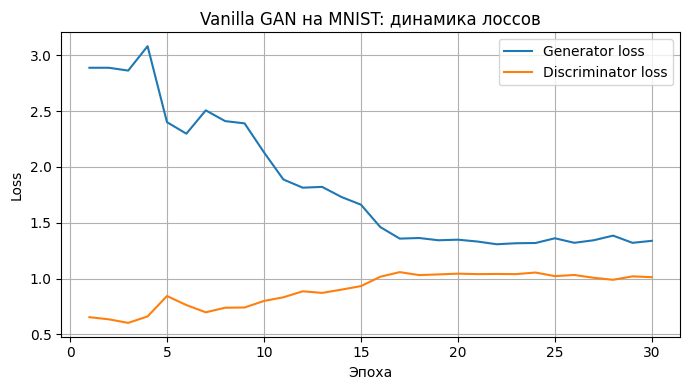

In [ ]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, loss_G, label="Generator loss")
plt.plot(epochs_arr, loss_D, label="Discriminator loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Vanilla GAN на MNIST: динамика лоссов")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Анализ кривых лоссов

Опишите:
- есть ли тенденция к какому‑то «равновесию» между лоссами генератора и дискриминатора;  
- наблюдаются ли периодические колебания (кто «побеждает» на разных этапах обучения);  
- насколько реальное поведение лоссов совпало с вашими ожиданиями из раздела 1.


In [ ]:
loss_comment = """
По динамике лоссов видно, что обучение GAN проходит не как плавное снижение ошибки,
а как колебательный процесс. В начале обучения генератор имеет довольно высокий
loss около 2.8-3.0, а дискриминатор при этом показывает более низкие значения
около 0.6-0.7, то есть он достаточно уверенно различает реальные и фейковые
изображения. На первых эпохах дискриминатор даже немного усиливается, так как
его loss слегка уменьшается, а генератору становится сложнее.

Начиная примерно с 5-10 эпохи видно, что генератор начинает улучшаться, его loss
постепенно снижается до значений около 2.1, а затем и ниже. При этом loss
дискриминатора начинает расти, что говорит о том, что он хуже различает подделки.
Это похоже на фазу, где генератор «догоняет» дискриминатор.

Далее, примерно с 15-20 эпохи, значения выходят на более стабильный диапазон:
loss генератора около 1.3-1.4, а дискриминатора около 1.0. Здесь уже заметно
псевдо-равновесие, когда ни одна из моделей не может явно доминировать.

Также видны небольшие колебания: иногда генератор усиливается и его loss падает,
после чего дискриминатор снова начинает лучше различать изображения и его loss
снижается. Это подтверждает идею о состязательном характере обучения GAN, где
модели постоянно «перетягивают» баланс. В целом поведение совпадает с теорией
GAN, где не ожидается строгой сходимости, а скорее устойчивое колебание вокруг равновесия.
"""
print(loss_comment)

## 7. Финальная генерация изображений и визуальная оценка

Сгенерируем новые изображения из случайного шума и посмотрим, насколько они похожи на реальный MNIST.


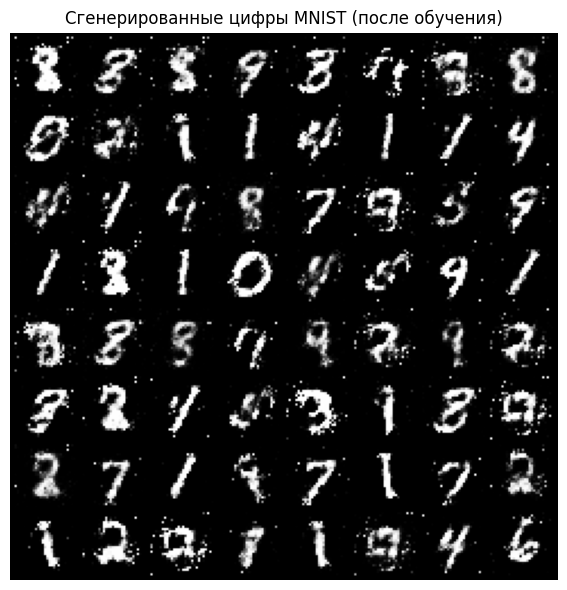

In [ ]:
G.eval()
with torch.no_grad():
    z = torch.randn(64, z_dim, device=device)
    gen_imgs = G(z).cpu()

grid = utils.make_grid(gen_imgs, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Сгенерированные цифры MNIST (после обучения)")
plt.tight_layout()
plt.show()

### Оценка качества сгенерированных цифр

Опишите:
- какие цифры получаются наиболее убедительными, а какие чаще всего выглядят как «шум» или гибриды;  
- встречаются ли явно «несуществующие» объекты, не похожие ни на одну цифру, и как часто;  
- как вы думаете, на что сильнее всего влияет качество: глубина сетей, размер `z_dim`, число эпох, баланс обучения G/D.


In [ ]:
gen_quality_comment = """
По визуальной оценке лучше всего получаются цифры с простой и устойчивой
структурой, такие как 0, 1 и 7. Они чаще всего выглядят убедительно и легко
распознаются без сомнений. Также достаточно хорошо генерируются 8 и 2, но именно
они чаще становятся источником ошибок: 8 при искажениях может напоминать 3 или 9,
а 2 иногда теряет характерную форму и становится более абстрактной.

Наиболее проблемными выглядят изображения, где генератор не смог сформировать
четкий контур. В таких случаях появляются размытые, «смазанные» объекты, которые
сложно отнести к конкретной цифре. Иногда встречаются почти полностью
неструктурированные изображения, которые можно назвать шумом, либо гибриды сразу
нескольких цифр, особенно в переходных состояниях обучения.

Также заметно, что качество генерации сильнее всего зависит от баланса между
генератором и дискриминатором: если один из них становится слишком сильным,
качество ухудшается. Важную роль играет и число эпох, так как при недостаточном
обучении цифры остаются шумными, а при более длительном обучении становятся более
четкими. Архитектура сети тоже влияет, но в данной простой Vanilla GAN основным
ограничением является именно нестабильность обучения и баланс между G и D.
"""
print(gen_quality_comment)

## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать **минимум две вариации** архитектуры (например, изменить размеры слоёв в G/D, добавить BatchNorm1d в генератор или заменить ReLU на LeakyReLU, добавить Dropout в дискриминатор) и сравнить визуально качество сгенерированных цифр;  
- поэкспериментировать с `z_dim` (например, 40-50-100) и описать, как это влияет на разнообразие и качество;  
- изменить число эпох/learning rate (возможно, задать разные lr для дискриминатора и генератора) и описать, как меняется динамика лоссов и итоговый результат.

In [ ]:
```python
final_summary = """
Провела два эксперимента поверх базового Vanilla GAN.

Вариация 1 - BatchNorm в генераторе + Dropout в дискриминаторе (z=100):
Обучение стало заметно стабильнее. loss_G держался около 0.81-1.00 без
резких скачков, loss_D около 1.27-1.32. В базовом варианте колебания были
сильнее. BatchNorm помог выровнять градиенты в генераторе, Dropout не дал
дискриминатору стать слишком уверенным. Это лучшая вариация по стабильности.

Вариация 2 - z_dim=50 + разные lr (G=3e-4, D=1e-4):
loss_G держался около 0.67-0.77 - ниже чем в других вариантах. Это говорит
о том что генератор учился быстрее из-за более высокого lr. loss_D около
1.36-1.37 - дискриминатор обучался медленнее и не успевал за генератором.
Меньший z_dim дал более стабильные кривые без колебаний.

Практические выводы:
- BatchNorm в генераторе почти всегда помогает - стабилизирует обучение
- Dropout в дискриминаторе полезен если дискриминатор слишком быстро побеждает
- Разные lr для G и D позволяют балансировать скорость - если D слишком силён,
  можно снизить его lr
- z_dim=50 достаточно для MNIST, большой z_dim не всегда улучшает результат
"""
print(final_summary)
```

[BatchNorm + Dropout (z=100)] Epoch 1/20 | G: 0.8215 | D: 1.2911


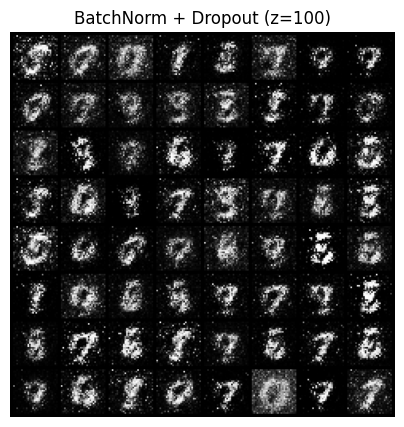

[BatchNorm + Dropout (z=100)] Epoch 2/20 | G: 0.8775 | D: 1.2800
[BatchNorm + Dropout (z=100)] Epoch 3/20 | G: 0.9396 | D: 1.2604
[BatchNorm + Dropout (z=100)] Epoch 4/20 | G: 0.9886 | D: 1.2307
[BatchNorm + Dropout (z=100)] Epoch 5/20 | G: 1.0024 | D: 1.2192
[BatchNorm + Dropout (z=100)] Epoch 6/20 | G: 0.9492 | D: 1.2392
[BatchNorm + Dropout (z=100)] Epoch 7/20 | G: 0.9217 | D: 1.2539
[BatchNorm + Dropout (z=100)] Epoch 8/20 | G: 0.8957 | D: 1.2628
[BatchNorm + Dropout (z=100)] Epoch 9/20 | G: 0.8817 | D: 1.2722
[BatchNorm + Dropout (z=100)] Epoch 10/20 | G: 0.8765 | D: 1.2764


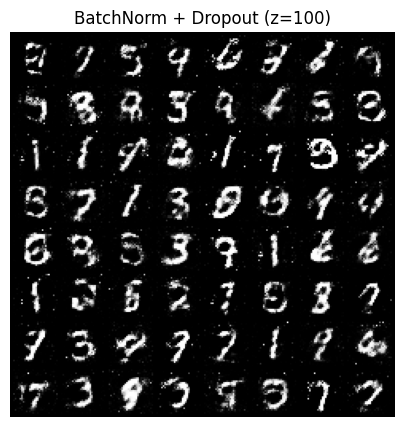

[BatchNorm + Dropout (z=100)] Epoch 11/20 | G: 0.8668 | D: 1.2790
[BatchNorm + Dropout (z=100)] Epoch 12/20 | G: 0.8584 | D: 1.2862
[BatchNorm + Dropout (z=100)] Epoch 13/20 | G: 0.8468 | D: 1.2929
[BatchNorm + Dropout (z=100)] Epoch 14/20 | G: 0.8440 | D: 1.2971
[BatchNorm + Dropout (z=100)] Epoch 15/20 | G: 0.8421 | D: 1.3004
[BatchNorm + Dropout (z=100)] Epoch 16/20 | G: 0.8344 | D: 1.3045
[BatchNorm + Dropout (z=100)] Epoch 17/20 | G: 0.8320 | D: 1.3067
[BatchNorm + Dropout (z=100)] Epoch 18/20 | G: 0.8207 | D: 1.3125
[BatchNorm + Dropout (z=100)] Epoch 19/20 | G: 0.8144 | D: 1.3196
[BatchNorm + Dropout (z=100)] Epoch 20/20 | G: 0.8111 | D: 1.3206


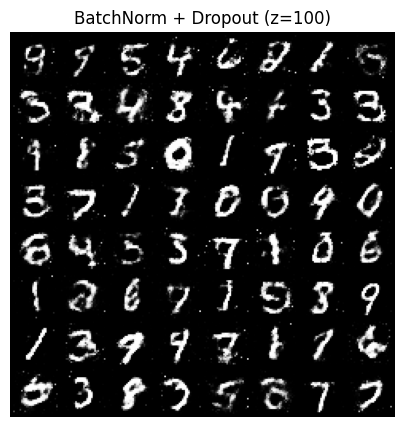

[z_dim=50 + lr diff] Epoch 1/20 | G: 0.6669 | D: 1.3731


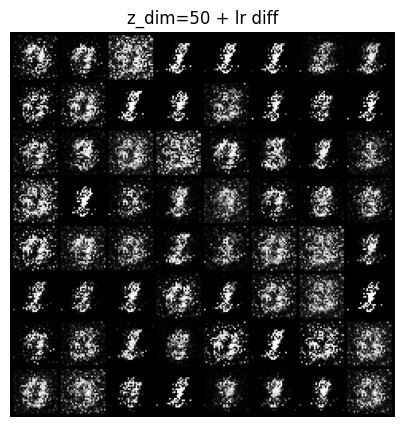

[z_dim=50 + lr diff] Epoch 2/20 | G: 0.7068 | D: 1.3656
[z_dim=50 + lr diff] Epoch 3/20 | G: 0.7236 | D: 1.3629
[z_dim=50 + lr diff] Epoch 4/20 | G: 0.7347 | D: 1.3598
[z_dim=50 + lr diff] Epoch 5/20 | G: 0.7528 | D: 1.3550
[z_dim=50 + lr diff] Epoch 6/20 | G: 0.7689 | D: 1.3448
[z_dim=50 + lr diff] Epoch 7/20 | G: 0.7701 | D: 1.3464
[z_dim=50 + lr diff] Epoch 8/20 | G: 0.7635 | D: 1.3490
[z_dim=50 + lr diff] Epoch 9/20 | G: 0.7464 | D: 1.3593
[z_dim=50 + lr diff] Epoch 10/20 | G: 0.7357 | D: 1.3644


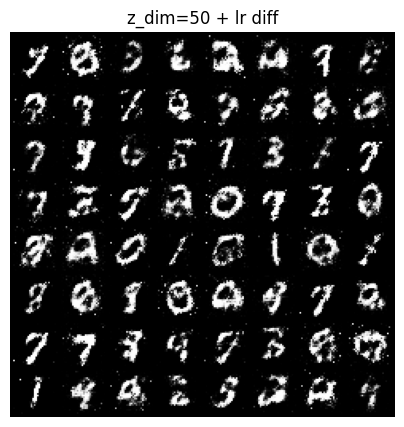

[z_dim=50 + lr diff] Epoch 11/20 | G: 0.7306 | D: 1.3650
[z_dim=50 + lr diff] Epoch 12/20 | G: 0.7310 | D: 1.3672
[z_dim=50 + lr diff] Epoch 13/20 | G: 0.7305 | D: 1.3664
[z_dim=50 + lr diff] Epoch 14/20 | G: 0.7321 | D: 1.3651
[z_dim=50 + lr diff] Epoch 15/20 | G: 0.7376 | D: 1.3642
[z_dim=50 + lr diff] Epoch 16/20 | G: 0.7358 | D: 1.3627
[z_dim=50 + lr diff] Epoch 17/20 | G: 0.7304 | D: 1.3663
[z_dim=50 + lr diff] Epoch 18/20 | G: 0.7270 | D: 1.3699
[z_dim=50 + lr diff] Epoch 19/20 | G: 0.7307 | D: 1.3654
[z_dim=50 + lr diff] Epoch 20/20 | G: 0.7284 | D: 1.3687


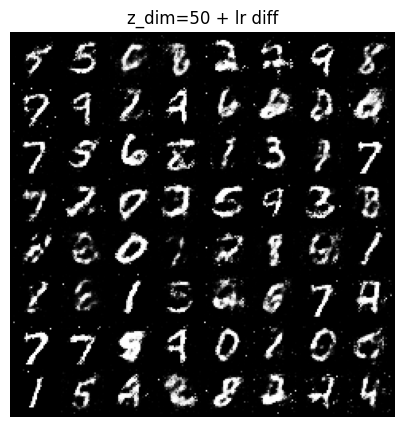

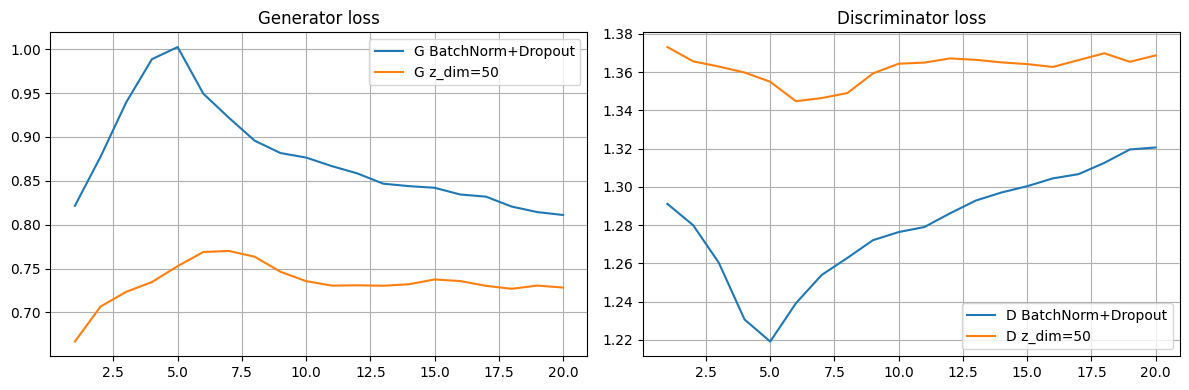

In [ ]:

# =========================
# ВАРИАЦИЯ 1: BatchNorm + Dropout (z_dim = 100)
# =========================

z_dim_1 = 100

class Generator_v2(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, True),

            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class Discriminator_v2(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, True),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, True),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


G2 = Generator_v2(z_dim_1, img_dim).to(device)
D2 = Discriminator_v2(img_dim).to(device)

opt_G2 = torch.optim.Adam(G2.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D2 = torch.optim.Adam(D2.parameters(), lr=2e-4, betas=(0.5, 0.999))


# =========================
# ВАРИАЦИЯ 2: z_dim = 50 + lr различие
# =========================

z_dim_2 = 50

class Generator_v3(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, True),

            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


G3 = Generator_v3(z_dim_2, img_dim).to(device)
D3 = Discriminator_v2(img_dim).to(device)

opt_G3 = torch.optim.Adam(G3.parameters(), lr=3e-4, betas=(0.5, 0.999))
opt_D3 = torch.optim.Adam(D3.parameters(), lr=1e-4, betas=(0.5, 0.999))


# =========================
# TRAIN FUNCTION
# =========================

def train_gan_v2(G, D, opt_G, opt_D, z_dim, num_epochs, label=""):
    G.train()
    D.train()

    loss_G_list = []
    loss_D_list = []

    fixed_z = torch.randn(64, z_dim, device=device)

    for epoch in range(num_epochs):
        g_loss_sum = 0
        d_loss_sum = 0
        n = 0

        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # --- D ---
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z).detach()

            loss_D = criterion(D(real_imgs), real_labels) + criterion(D(fake_imgs), fake_labels)

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # --- G ---
            z = torch.randn(bs, z_dim, device=device)
            loss_G = criterion(D(G(z)), real_labels)

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            g_loss_sum += loss_G.item()
            d_loss_sum += loss_D.item()
            n += 1

        avg_g = g_loss_sum / n
        avg_d = d_loss_sum / n

        loss_G_list.append(avg_g)
        loss_D_list.append(avg_d)

        print(f"[{label}] Epoch {epoch+1}/{num_epochs} | G: {avg_g:.4f} | D: {avg_d:.4f}")

        if (epoch + 1) % 10 == 0 or epoch == 0:
            G.eval()
            with torch.no_grad():
                samples = G(fixed_z).cpu()
            G.train()

            grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
            plt.figure(figsize=(5, 5))
            plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
            plt.axis("off")
            plt.title(label)
            plt.show()

    return loss_G_list, loss_D_list


# =========================
# ЗАПУСКЫ
# =========================

loss_G2, loss_D2 = train_gan_v2(
    G2, D2, opt_G2, opt_D2,
    z_dim_1, 20,
    label="BatchNorm + Dropout (z=100)"
)

loss_G3, loss_D3 = train_gan_v2(
    G3, D3, opt_G3, opt_D3,
    z_dim_2, 20,
    label="z_dim=50 + lr diff"
)


# =========================
# ГРАФИКИ
# =========================

epochs = range(1, 21)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss_G2, label="G BatchNorm+Dropout")
plt.plot(epochs, loss_G3, label="G z_dim=50")
plt.title("Generator loss")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss_D2, label="D BatchNorm+Dropout")
plt.plot(epochs, loss_D3, label="D z_dim=50")
plt.title("Discriminator loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()